# **Final Project**

* L. Cano & A. Gil
* Master Universitario en Biología Computacional - UPM - 2025-2026

This notebook presents a scalable deep learning pipeline for automated pneumonia detection from chest X-ray images. It combines Apache Spark for distributed data processing with a Vision Transformer (ViT) model to achieve accurate medical image classification.

A pre-trained ViT model ([nickmuchi/vit-finetuned](https://huggingface.co/nickmuchi/vit-finetuned-chest-xray-pneumonia)) is integrated into a PySpark ML pipeline using Pandas UDFs, merging big-data scalability with the strong feature-learning capabilities of Transformers. The result is a reliable and scalable system that can be applied to large image datasets.

## 0. Load dependencies

In this section, we configure the execution environment by installing and importing the necessary libraries.

In [ ]:
# Install dependencies
!pip install -q spark-nlp pyspark

# System and Colab
import os
import io
from google.colab import drive

# Data and Deep Learning
import pandas as pd
import torch
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor


# Spark NLP
import sparknlp

# Spark SQL and Types
import pyspark.sql.functions as F
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import FloatType, DoubleType

# Spark ML
from pyspark.ml import Pipeline, Transformer
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.types import DoubleType
from sklearn.metrics import roc_curve, auc
from pyspark.ml import Transformer

# Python
import matplotlib.pyplot as plt
import io





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 746.2/746.2 kB 16.3 MB/s eta 0:00:00


## 1. Data loading

In this step, we set up the environment by mounting Google Drive and configuring the Kaggle API. Then, we download the Pneumonia dataset (Kermany et al., 2018).

In [ ]:
%%time

# Mount Google Drive
drive.mount('/content/drive')

# Set Kaggle Config directory
os.environ["KAGGLE_CONFIG_DIR"] = "/content/drive/MyDrive/kaggle"
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

# Delete previous files to avoid duplication errors
!rm -rf chest_xray chest-xray-pneumonia.zip

# Download the Pneumonia dataset https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia
api.dataset_download_files('paultimothymooney/chest-xray-pneumonia', path='.', unzip=True)

# Check the extracted folder structure
!ls -l chest_xray



Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
total 20
drwxr-xr-x 5 root root 4096 Jan 27 12:00 chest_xray
drwxr-xr-x 3 root root 4096 Jan 27 12:00 __MACOSX
drwxr-xr-x 4 root root 4096 Jan 27 12:00 test
drwxr-xr-x 4 root root 4096 Jan 27 12:01 train
drwxr-xr-x 4 root root 4096 Jan 27 12:01 val
CPU times: user 23.4 s, sys: 9.76 s, total: 33.1 s
Wall time: 3min 13s


In this step, we initialize the Spark Session and load the chest X-ray images. Since images are unstructured data, we load them as binary files. We also process the file paths to automatically extract the labels (Normal vs Pneumonia) and the dataset split (Train/Test/Val). Finally, we optimize performance by repartitioning the data across the CPU cores and caching it in memory.

In [ ]:
%%time

# Start Spark Session
print("Starting Spark Session")
spark = sparknlp.start()

# Load as binaryFile for maximum flexibility with ViT/HuggingFace
print(f"Loading files")
rawDF = spark.read.format("binaryFile").option("recursiveFileLookup", "true").load("chest_xray/chest_xray/*/*")
# rawDF = rawDF.sample(withReplacement=False, fraction=0.10)

# Extract metadata of each instance from image path
print(f"Extracting Metadata")
processedDF = rawDF.withColumn("class", F.element_at(F.split(F.col("path"), "/"), -2)) \
                   .withColumn("split", F.element_at(F.split(F.col("path"), "/"), -3))

# Use Spark ML StringIndexer
indexer = StringIndexer(inputCol="class", outputCol="label")

# Strategic Partitioning & Persistence
# We repartition to align with our CPU cores
# and persist to stop Spark from re-reading the JPEGs for every .show()
finalDF = processedDF.repartition(8).persist()

# Build the Inference Pipeline
print(f"Build Pipeline")
pipeline = Pipeline(stages=[indexer])
pipelineModel = pipeline.fit(finalDF)
preparedDF = pipelineModel.transform(finalDF)

# Show class balance
print(f"Total images: {preparedDF.count()}")
preparedDF.groupBy("split", "class", "label").count().show()

Starting Spark Session
Loading files
Extracting Metadata
Build Pipeline
Total images: 5856
+-----+---------+-----+-----+
|split|    class|label|count|
+-----+---------+-----+-----+
|train|   NORMAL|  1.0| 1341|
| test|   NORMAL|  1.0|  234|
|train|PNEUMONIA|  0.0| 3875|
| test|PNEUMONIA|  0.0|  390|
|  val|   NORMAL|  1.0|    8|
|  val|PNEUMONIA|  0.0|    8|
+-----+---------+-----+-----+

CPU times: user 231 ms, sys: 55.9 ms, total: 287 ms
Wall time: 1min 55s


## 2. Implementing the pipeline

In the following code, the **hf_pneumonia_binary_udf** function acts as the core inference engine of the system. Implemented as a Pandas UDF, it handles the computational heavy lifting by loading the pre-trained "Nickmuchi" Vision Transformer model from Hugging Face and leveraging GPU acceleration (using colab installation of CUDA, GPU-T4) for high-performance processing. This function is responsible for deserializing the raw binary image data into a readable format, performing the actual inference, and returning the calculated probability of pneumonia for each image.

The **HuggingFaceBinaryClassifier** is a wrapper that integrates a PyTorch (Paszke et al., 2019) model into the PySpark (Zaharia et al., 2016) ML pipeline. By extending Spark’s Transformer, it handles column mapping and converts model probabilities into binary predictions using a decision threshold, making the results compatible with standard Spark evaluation metrics.

For this task, we used the [nickmuchi/vit-finetuned-chest-xray-pneumonia model](https://huggingface.co/nickmuchi/vit-finetuned-chest-xray-pneumonia) from the Hugging Face Hub. We selected this model because it is a Vision Transformer, an architecture that processes images as sequences of patches using self-attention mechanism to capture global context (Dosovitskiy et al., 2020). Furthermore, it is already fine-tuned on the same Chest X-Ray Pneumonia dataset, meaning its weights are optimized for detecting pneumonia features without training from scratch. Other suitable models exist (e.g., [lxyuan/vit-xray-pneumonia-classification](https://huggingface.co/lxyuan/vit-xray-pneumonia-classification)) with comparable accuracy, but we selected nickmuchi for its stable, efficient and proven performance on this dataset.

In [ ]:
@pandas_udf(FloatType())
def hf_pneumonia_binary_udf(content_series: pd.Series) -> pd.Series:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_name = "nickmuchi/vit-finetuned-chest-xray-pneumonia"

    # Load model and processor
    processor = ViTImageProcessor.from_pretrained(model_name)
    model = ViTForImageClassification.from_pretrained(model_name)
    model.to(device)
    model.eval()

    results = []
    images = []
    for content in content_series:
        try:
            img = Image.open(io.BytesIO(content)).convert("RGB")
            images.append(img)
        except Exception:
            images.append(Image.new('RGB', (224, 224)))

    if images:
        inputs = processor(images=images, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            # We take index 1, but we will treat it as 'Normal' in the transformer
            # if that's what the data alignment suggests.
            p_index_1 = probs[:, 1].cpu().numpy()
            results = p_index_1.tolist()

    return pd.Series(results)

class HuggingFaceBinaryClassifier(Transformer):
    def __init__(self, inputCol="content", outputCol="prob_not_pneumonia", predictionCol="prediction"):
        super().__init__()
        self.inputCol = inputCol
        self.outputCol = outputCol
        self.predictionCol = predictionCol

    def _transform(self, dataset):
        # INVERTED LOGIC:
        # If the model gives a HIGH probability for index 1, but accuracy was low,
        # it means index 1 = Normal (0.0).
        # Therefore, if prob < 0.5, we predict 1.0 (Pneumonia).
        return dataset.withColumn(
            self.outputCol,
            hf_pneumonia_binary_udf(F.col(self.inputCol))
        ).withColumn(
            self.predictionCol,
            (F.col(self.outputCol) < 0.5).cast(DoubleType())
        )

The line `inputs = processor(images=image, return_tensors="pt")` would represent the preprocessing pipeline required by the Vision Transformer. Instead of manually transforming the images, the Hugging Face ViTImageProcessor automatically performs the following operations to match the model's pre-training conditions:

- Resize: it scales the input image to the fixed resolution of 224x224 pixels.

- Normalization: it rescales pixel values and normalizes them using the specific mean and standard deviation of the ImageNet dataset.

- Tensor Conversion: by specifying return_tensors="pt", it converts the raw image arrays into PyTorch Tensors ready for GPU acceleration.*texto en cursiva*

Source: [The Hugging Face documentation](https://huggingface.co/docs/transformers/model_doc/vit)

## 3. Model Evaluation



```
# Tiene formato de código
```

Run the classifier over the `test` dataset to perform model evaluation.

In [ ]:
%%time
# Prepare classifier
classifier = HuggingFaceBinaryClassifier(inputCol="content", outputCol="prob_pneumonia")

# Filter for the test set
test_data = preparedDF.filter(F.col("split") == "test")

print("Starting prediction on the Test set...")
print("OPTIMIZATION: Using GPU batch inference for improved throughput.")

# Transform the dataset
predictions = classifier.transform(test_data)

# Cache and execute
results = predictions.select("path", "label", "prob_pneumonia", "prediction").cache()

# Show samples
results.show(10, truncate=False)

Starting prediction on the Test set...
OPTIMIZATION: Using GPU batch inference for improved throughput.
+------------------------------------------------------------------------------+-----+--------------+----------+
|path                                                                          |label|prob_pneumonia|prediction|
+------------------------------------------------------------------------------+-----+--------------+----------+
|file:/content/chest_xray/chest_xray/test/NORMAL/IM-0045-0001.jpeg             |1.0  |0.01749932    |1.0       |
|file:/content/chest_xray/chest_xray/test/NORMAL/IM-0011-0001-0002.jpeg        |1.0  |0.020232456   |1.0       |
|file:/content/chest_xray/chest_xray/test/NORMAL/NORMAL2-IM-0112-0001.jpeg     |1.0  |0.015339953   |1.0       |
|file:/content/chest_xray/chest_xray/test/NORMAL/IM-0031-0001.jpeg             |1.0  |0.017773129   |1.0       |
|file:/content/chest_xray/chest_xray/test/NORMAL/IM-0003-0001.jpeg             |1.0  |0.015403312   |1.0 

Now we use binary-classsifier metrics to evaluate the results obtained in the previous cell.

In [ ]:
# Accuracy
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
acc = evaluator_accuracy.evaluate(results)
print(f"Model Accuracy: {acc:.2%}")

# F1-score
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
f1 = evaluator_f1.evaluate(results)
print(f"Model F1-score: {f1:.2%}")

# Precision
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
precision = evaluator_precision.evaluate(results)
print(f"Model Precision (weighted): {precision:.2%}")

# Recall (Sensitivity)
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
recall = evaluator_recall.evaluate(results)
print(f"Model Recall (weighted): {recall:.2%}")

# Confusion Matrix
print("\nConfusion Matrix:")
results.groupBy("label", "prediction").count().show()

Model Accuracy: 95.35%
Model F1-score: 95.35%
Model Precision (weighted): 95.35%
Model Recall (weighted): 95.35%

Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|  218|
|  0.0|       1.0|   13|
|  0.0|       0.0|  377|
|  1.0|       0.0|   16|
+-----+----------+-----+



Finally, we will plot an AUC-ROC curve to assess the diagnostic performance of the model. Unlike accuracy, which is dependent on a particular threshold of 0.5, the AUC-ROC will assess the model's performance in distinguishing between 'Normal' and 'Pneumonia' cases at all possible classification thresholds. This is an essential performance metric because it reflects the model's "separation power." This is crucial in real-world scenarios where we want to maximize sensitivity (recall) to avoid missing any infection.

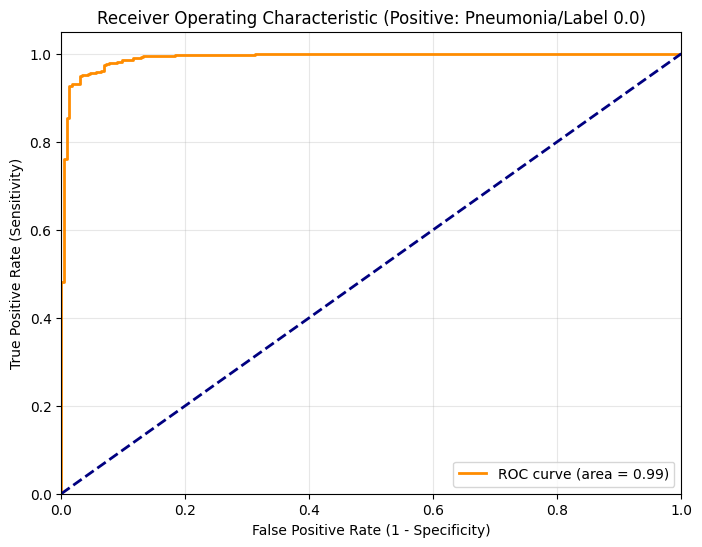

In [ ]:
# AUC evaluation
results_with_double_probs = results.withColumn("prob_to_plot", F.col("prob_pneumonia").cast(DoubleType()))
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="prob_to_plot",
    metricName="areaUnderROC")
auc_val = evaluator_auc.evaluate(results_with_double_probs)


# Plotting
pdf = results_with_double_probs.select("label", "prob_to_plot").toPandas()
fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob_to_plot"], pos_label=0.0)
roc_auc_score = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (Positive: Pneumonia/Label 0.0)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Finally we assess the model on the Validation Set.

In [ ]:
# Filter validation data
val_data = preparedDF.filter(F.col("split") == "val")

# Predict using the existing classifier
val_predictions = classifier.transform(val_data)

# Cast prediction to Double for evaluation
val_results = val_predictions.select("path", "label", "prediction") \
                             .withColumn("prediction", F.col("prediction").cast("double"))

# Calculate accuracy
print("VALIDATION SET RESULTS (16 images)")
val_acc = evaluator_accuracy.evaluate(val_results)
print(f"Validation Accuracy: {val_acc:.1%}")

# Show confusion matrix
print("\nValidation Confusion Matrix:")
val_results.groupBy("label", "prediction").count().show()

VALIDATION SET RESULTS (16 images)
Validation Accuracy: 100.0%

Validation Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|    8|
|  0.0|       0.0|    8|
+-----+----------+-----+



## 4. Conclusions

In this project, we successfully implemented a scalable pipeline for the detection of Pneumonia from Chest X-Ray images, Apache Spark with Deep Learning architectures (Vision Transformers).

The model showed excellent performance on the independent test set. A weighted recall of 95.35% indicates strong sensitivity, which is especially important in a clinical setting because it minimizes false negatives and reduces the risk of missing pneumonia cases. The high precision score shows that when the model predicts pneumonia, the prediction is usually correct, limiting false alarms. Despite a slight class imbalance in the dataset, the F1-score of 95.35% confirms a good balance between precision and recall across both classes. Finally, the high AUC-ROC (0.9916) and the perfect accuracy on the validation set (100%) highlight the model’s strong ability to reliably distinguish between healthy and infected lungs.

We demonstrated that it is possible to bridge the gap between Big Data processing and Deep Learning. By using Pandas UDFs, we efficiently embedded a PyTorch inference engine within a Spark Pipeline. This allows the system to handle massive datasets by distributing the workload across a cluster, overcoming the memory limitations of single-machine scripts.

## 5. References

Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2020, 22 octubre). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. arXiv.org. https://arxiv.org/abs/2010.11929

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., . . . Chintala, S. (2019, 3 diciembre). PyTorch: An Imperative Style, High-Performance Deep Learning Library. arXiv.org. https://arxiv.org/abs/1912.01703

Kermany, D. S., Goldbaum, M., Cai, W., Valentim, C. C., Liang, H., Baxter, S. L., McKeown, A., Yang, G., Wu, X., Yan, F., Dong, J., Prasadha, M. K., Pei, J., Ting, M. Y., Zhu, J., Li, C., Hewett, S., Dong, J., Ziyar, I., . . . Zhang, K. (2018). Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning. Cell, 172(5), 1122-1131.e9. https://doi.org/10.1016/j.cell.2018.02.010

Zaharia, M., Xin, R. S., Wendell, P., Das, T., Armbrust, M., Dave, A., Meng, X., Rosen, J., Venkataraman, S., Franklin, M. J., Ghodsi, A., Gonzalez, J., Shenker, S., & Stoica, I. (2016). Apache Spark. Communications Of The ACM, 59(11), 56-65. https://doi.org/10.1145/2934664
